In [32]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [33]:
df = pd.read_csv(r"C:\Users\aksha\OneDrive\Desktop\Weather Project\DailyDelhiClimateTest.csv")
df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2017-01-01,15.913043,85.869565,2.743478,59.000000
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333


In [34]:
df.shape

(114, 5)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          114 non-null    object 
 1   meantemp      114 non-null    float64
 2   humidity      114 non-null    float64
 3   wind_speed    114 non-null    float64
 4   meanpressure  114 non-null    float64
dtypes: float64(4), object(1)
memory usage: 4.6+ KB


In [36]:
df.describe()


,meantemp,humidity,wind_speed,meanpressure
count,114.000000,114.000000,114.000000,114.000000
mean,21.713079,56.258362,8.143924,1004.035090
std,6.360072,19.068083,3.588049,89.474692
min,11.000000,17.750000,1.387500,59.000000
25%,16.437198,39.625000,5.563542,1007.437500
50%,19.875000,57.750000,8.069444,1012.739316
75%,27.705357,71.902778,10.068750,1016.739583
max,34.500000,95.833333,19.314286,1022.809524


In [37]:
df.columns.tolist()

['date', 'meantemp', 'humidity', 'wind_speed', 'meanpressure']

In [38]:
df.dtypes


date             object
meantemp        float64
humidity        float64
wind_speed      float64
meanpressure    float64
dtype: object

In [39]:
df.isnull().sum()

date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

In [40]:
df.duplicated().sum()

np.int64(0)

In [41]:
df['date'].dtype

dtype('O')

In [42]:
df[df['meanpressure']<900]

,date,meantemp,humidity,wind_speed,meanpressure
0,2017-01-01,15.913043,85.869565,2.743478,59.0


In [43]:
df.loc[df['meanpressure']<900,'meanpressure']=np.nan
df['meanpressure']= df['meanpressure'].fillna(df['meanpressure'].median())

In [45]:
df['date']=pd.to_datetime(df['date'])
df['date'].dtype


dtype('<M8[ns]')

In [46]:
df.describe()

,date,meantemp,humidity,wind_speed,meanpressure
count,114,114.000000,114.000000,114.000000,114.000000
mean,2017-02-26 12:00:00,21.713079,56.258362,8.143924,1012.402836
min,2017-01-01 00:00:00,11.000000,17.750000,1.387500,998.625000
25%,2017-01-29 06:00:00,16.437198,39.625000,5.563542,1007.767857
50%,2017-02-26 12:00:00,19.875000,57.750000,8.069444,1012.923077
75%,2017-03-26 18:00:00,27.705357,71.902778,10.068750,1016.739583
max,2017-04-24 00:00:00,34.500000,95.833333,19.314286,1022.809524
std,NaN,6.360072,19.068083,3.588049,5.684872


In [47]:
df['meantemp'].mean()
df['humidity'].median()
np.std(df['meantemp'])

6.3321153536549115

In [48]:
df.set_index('date',inplace=True)
df.head()

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2017-01-01,15.913043,85.869565,2.743478,1012.923077
2017-01-02,18.500000,77.222222,2.894444,1018.277778
2017-01-03,17.111111,81.888889,4.016667,1018.333333
2017-01-04,18.700000,70.050000,4.545000,1015.700000
2017-01-05,18.388889,74.944444,3.300000,1014.333333


In [50]:
df.resample('ME').mean()

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2017-01-31,15.710873,77.188256,7.162982,1017.539659
2017-02-28,18.349981,64.375728,7.566294,1015.574251
2017-03-31,23.753760,48.009694,8.884385,1010.469641
2017-04-30,30.753663,30.408185,9.128446,1004.564831


In [51]:
df.corr()

,meantemp,humidity,wind_speed,meanpressure
meantemp,1.000000,-0.857726,0.217743,-0.871295
humidity,-0.857726,1.000000,-0.340507,0.765655
wind_speed,0.217743,-0.340507,1.000000,-0.183414
meanpressure,-0.871295,0.765655,-0.183414,1.000000


In [52]:
df.nlargest(5,'meantemp')
df.nsmallest(5,'humidity')

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2017-04-11,29.250000,17.750000,15.512500,1006.250000
2017-04-10,27.857143,19.428571,19.314286,1008.571429
2017-04-09,27.125000,21.125000,14.125000,1010.625000
2017-04-19,33.500000,24.125000,9.025000,1000.875000
2017-04-06,31.222222,26.000000,13.577778,1002.888889


In [53]:
df[df['wind_speed']>15]

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2017-02-24,19.125000,40.375000,16.662500,1016.125000
2017-03-26,29.100000,37.100000,17.590000,1010.200000
2017-04-10,27.857143,19.428571,19.314286,1008.571429
2017-04-11,29.250000,17.750000,15.512500,1006.250000


In [54]:
df['month']= df.index.month
df['day_of_week']=df.index.dayofweek
df['temp_category']=pd.cut(df['meantemp'],bins=[0,15,25,40],labels=['Cool','Mild','Hot'])
df['temp_category'].value_counts()

temp_category
Mild    67
Hot     34
Cool    13
Name: count, dtype: int64

In [55]:
df.head()

,meantemp,humidity,wind_speed,meanpressure,month,day_of_week,temp_category
date,,,,,,,
2017-01-01,15.913043,85.869565,2.743478,1012.923077,1,6,Mild
2017-01-02,18.500000,77.222222,2.894444,1018.277778,1,0,Mild
2017-01-03,17.111111,81.888889,4.016667,1018.333333,1,1,Mild
2017-01-04,18.700000,70.050000,4.545000,1015.700000,1,2,Mild
2017-01-05,18.388889,74.944444,3.300000,1014.333333,1,3,Mild


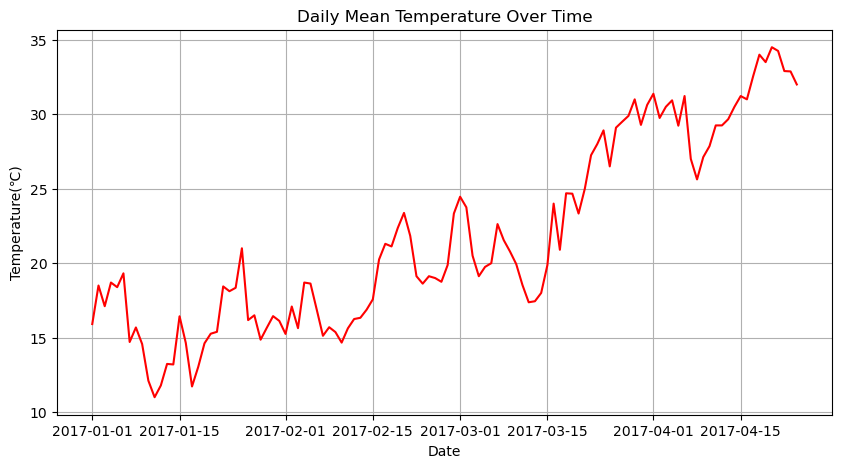

<Figure size 640x480 with 0 Axes>

In [71]:
plt.figure(figsize=(10,5))
plt.plot(df.index,df['meantemp'],
color='red')
plt.title('Daily Mean Temperature Over Time')
plt.xlabel('Date')
plt.ylabel('Temperature(℃)')
plt.grid(True)
plt.show()
plt.tight_layout()






















           

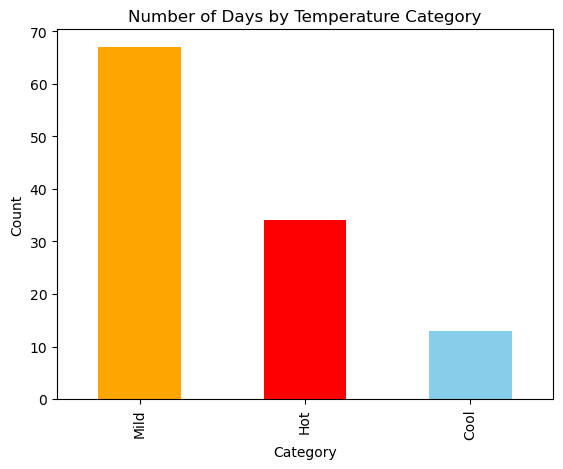

<Figure size 640x480 with 0 Axes>

In [72]:
df['temp_category'].value_counts().plot(kind='bar', color=['orange','red','skyblue'])
plt.title('Number of Days by Temperature Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()
plt.tight_layout()

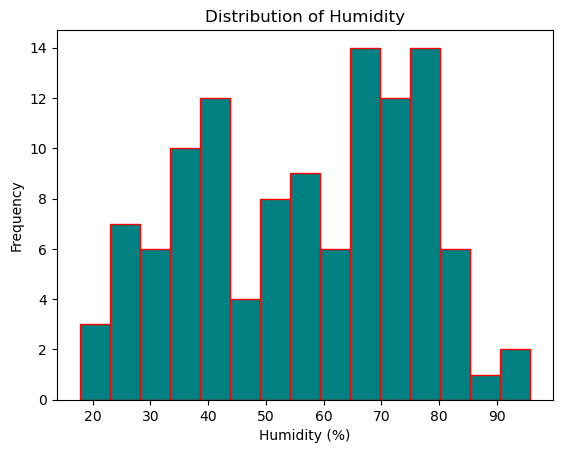

<Figure size 640x480 with 0 Axes>

In [73]:
plt.hist(df['humidity'], bins=15, color='teal', edgecolor='red')
plt.title('Distribution of Humidity')
plt.xlabel('Humidity (%)')
plt.ylabel('Frequency')
plt.show()
plt.tight_layout()

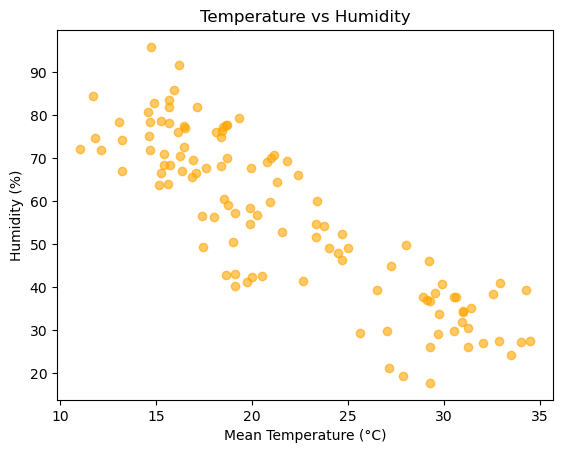

<Figure size 640x480 with 0 Axes>

In [75]:
plt.scatter(df['meantemp'], df['humidity'], color='orange', alpha=0.6)
plt.title('Temperature vs Humidity')
plt.xlabel('Mean Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.show()
plt.tight_layout()

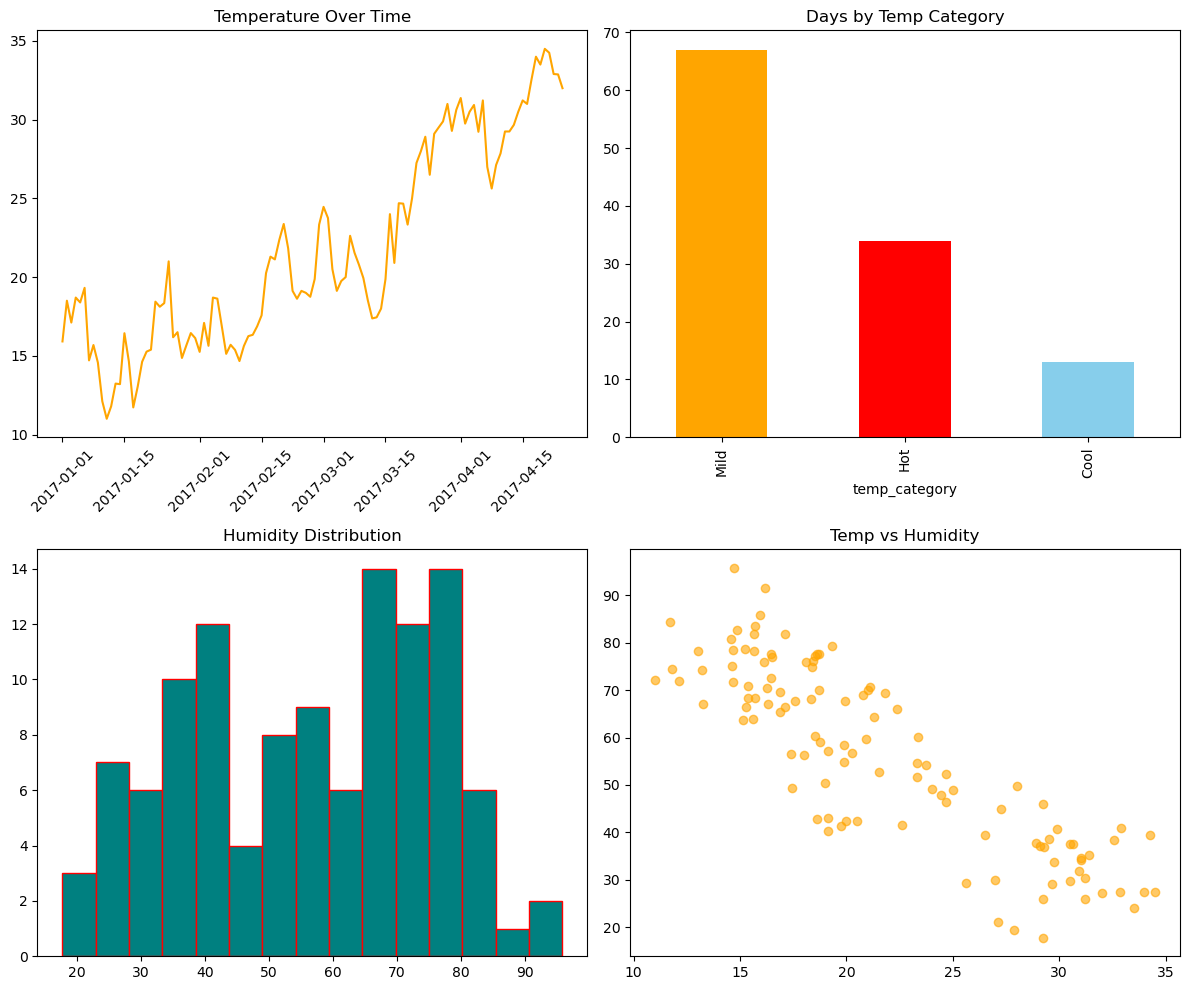

In [87]:
fig, axes = plt.subplots(2, 2, figsize=(12,10))

axes[0,0].plot(df.index, df['meantemp'], color='orange')
axes[0,0].set_title('Temperature Over Time')
axes[0,0].tick_params(axis='x',rotation=45)

df['temp_category'].value_counts().plot(kind='bar', ax=axes[0,1], color=['orange','red','skyblue'])
axes[0,1].set_title('Days by Temp Category')

axes[1,0].hist(df['humidity'], bins=15, color='teal', edgecolor='red')
axes[1,0].set_title('Humidity Distribution')

axes[1,1].scatter(df['meantemp'], df['humidity'], color='orange', alpha=0.6)
axes[1,1].set_title('Temp vs Humidity')

plt.tight_layout()

fig.savefig(r'C:\Users\aksha\OneDrive\Desktop\Weather Project\weather_analysis_summary.png',dpi=150,bbox_inches='tight')

plt.show()

